# Summary Statistics:

1. Mann-Whitney U — text length: Depression vs None  
2. Chi-Squared — high/low sentiment vs mental health class  
3. Kruskal-Wallis — sentiment scores across all classes

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv(
    'datasets/processed/mental_health_engineered.zip',
    compression='zip'
)

df['label'] = df['label'].fillna('None')
print(df['label'].value_counts())
print(df.shape)

Depression              28565
None                    18214
Anxiety                  6453
Bipolar                  5401
ADHD                     2961
PTSD                     2495
Personality disorder      895
Name: label, dtype: int64
(64984, 9)


## Test 1 — Mann-Whitney U

Null hypothesis (H₀): Posts from people showing signs of mental illness (Depression) are *not* systematically longer or shorter than posts from people without (None).  
Alternative (H₁): The two groups differ in post length (two-sided).

In [4]:
dep  = df[df['label'] == 'Depression']['Post_length'].dropna()
none = df[df['label'] == 'None']['Post_length'].dropna()

stat_mwu, p_mwu = stats.mannwhitneyu(dep, none, alternative='two-sided')

print(f'Depression  n={len(dep):,}  median={dep.median():.1f} words')
print(f'None        n={len(none):,}  median={none.median():.1f} words')
print(f'Mann-Whitney U = {stat_mwu:,.0f}')
print(f'p-value        = {p_mwu:.4e}')
if p_mwu < 0.05:
    print('=> Reject H₀ at α=0.05: post lengths differ significantly.')
else:
    print('=> Fail to reject H₀ at α=0.05.')

Depression  n=28,565  median=105.0 words
None        n=18,214  median=17.0 words
Mann-Whitney U = 420,165,174
p-value        = 0.0000e+00
=> Reject H₀ at α=0.05: post lengths differ significantly.


### Conclusion — Mann-Whitney U Test

We reject H₀ (U = 420,165,174, p ≈ 0). Depression posts are systematically and substantially longer than posts with no label.

- Dataset characteristics: The dataset contains 64,984 posts across 7 class labels. The Depression class is the largest labeled group, while the None class serves as a control group for this comparison.
- Feature behavior: Post length is skewed heavily to the right in both groups, with extreme outliers reaching thousands of words. This is consistent with the venting behavior documented in the feature engineering analysis. This is shown in the 99th-percentile cap used in the boxplot.
- Key finding: Depression posts have a median of 105 words vs. only 17 words for None posts, which means posts that show signs of depression tend to be much longer than posts that show no signs. This is not a marginal effect. It reflects a real behavioral pattern where users with symptoms of depression use social media as an outlet for their complicated emotions.
- Outliers: Both groups contain extreme outliers, but Depression's upper tail is far longer. This is to be expected, as they represent users writing extended personal narratives. They should be preserved for modeling.
- Implications: Post length is a strong, statistically validated discriminative feature between mentally ill and non-mentally-ill posts. It will likely carry high importance in any classification model. Since the distribution is not normal and heavily skewed, tree-based models or models with log-transformed features will handle it better than linear ones that assume normality.

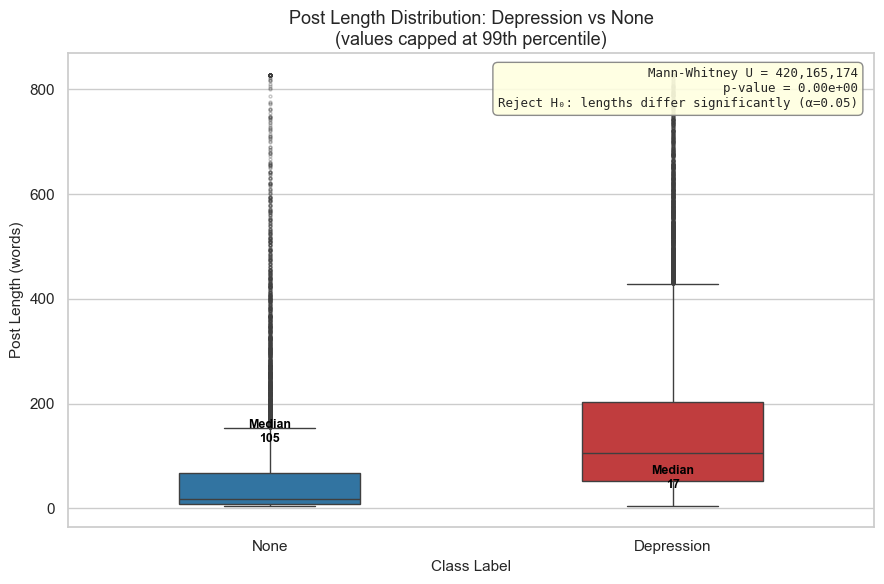

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))

plot_data = df[df['label'].isin(['Depression', 'None'])][['label', 'Post_length']].dropna()
plot_data_clipped = plot_data.copy()
cap = plot_data_clipped['Post_length'].quantile(0.99)
plot_data_clipped['Post_length'] = plot_data_clipped['Post_length'].clip(upper=cap)

palette = {'Depression': '#d62728', 'None': '#1f77b4'}
sns.boxplot(
    data=plot_data_clipped,
    x='label', y='Post_length',
    palette=palette,
    width=0.45,
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)

for i, (grp, color) in enumerate(palette.items()):
    med = plot_data_clipped[plot_data_clipped['label'] == grp]['Post_length'].median()
    ax.text(i, med + cap * 0.02, f'Median\n{med:.0f}', ha='center', va='bottom',
            fontsize=9, color='black', fontweight='bold')

conclusion = (
    f'Mann-Whitney U = {stat_mwu:,.0f}\n'
    f'p-value = {p_mwu:.2e}\n'
    + ('Reject H₀: lengths differ significantly (α=0.05)' if p_mwu < 0.05
       else 'Fail to reject H₀ (α=0.05)')
)
ax.text(0.98, 0.97, conclusion,
        transform=ax.transAxes, va='top', ha='right',
        fontsize=9, family='monospace',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray', alpha=0.9))

ax.set_title('Post Length Distribution: Depression vs None\n(values capped at 99th percentile)', fontsize=13)
ax.set_xlabel('Class Label', fontsize=11)
ax.set_ylabel('Post Length (words)', fontsize=11)
plt.tight_layout()
plt.show()

## Test 2 — Chi-Squared

Null hypothesis (H₀): Whether a post is high- or low-sentiment is unrelated to which mental health class it belongs to.  
Alternative (H₁): Sentiment polarity and class label are associated.

In [6]:
df_chi = df[df['label'] != 'None'].dropna(subset=['Vader_variable', 'label']).copy()
df_chi['Sentiment'] = df_chi['Vader_variable'].apply(lambda v: 'High' if v >= 0 else 'Low')

contingency = pd.crosstab(df_chi['Sentiment'], df_chi['label'])
print('Contingency table (Sentiment × Class):')
print(contingency)

chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)

print(f'\nChi² = {chi2:.4f}   dof = {dof}   p-value = {p_chi2:.4e}')
if p_chi2 < 0.05:
    print('=> Reject H₀ at α=0.05: sentiment polarity is associated with class.')
else:
    print('=> Fail to reject H₀ at α=0.05.')

Contingency table (Sentiment × Class):
label      ADHD  Anxiety  Bipolar  Depression  PTSD  Personality disorder
Sentiment                                                                
High       1796     2274     2564        8658   806                   430
Low        1165     4179     2837       19907  1689                   465

Chi² = 1567.9764   dof = 5   p-value = 0.0000e+00
=> Reject H₀ at α=0.05: sentiment polarity is associated with class.


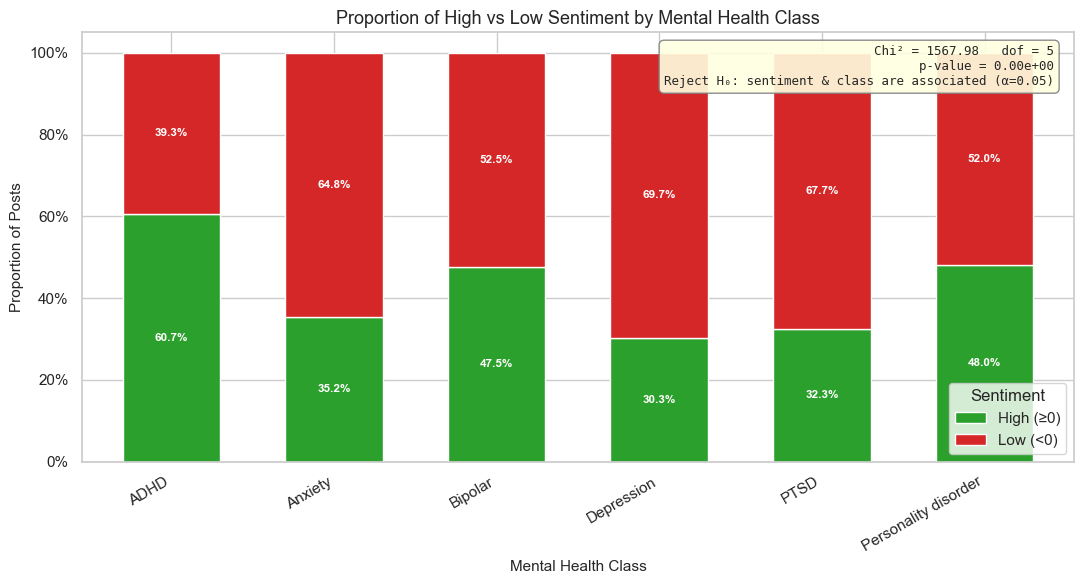

In [7]:
proportions = contingency.div(contingency.sum(axis=0), axis=1).T
proportions = proportions[['High', 'Low']]

fig, ax = plt.subplots(figsize=(11, 6))

colors = ['#2ca02c', '#d62728']
proportions.plot(kind='bar', stacked=True, color=colors, ax=ax, width=0.6, edgecolor='white')

for container in ax.containers:
    for bar in container:
        h = bar.get_height()
        if h > 0.04:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + h / 2,
                f'{h:.1%}',
                ha='center', va='center', fontsize=8.5, color='white', fontweight='bold'
            )

conclusion = (
    f'Chi² = {chi2:.2f}   dof = {dof}\n'
    f'p-value = {p_chi2:.2e}\n'
    + ('Reject H₀: sentiment & class are associated (α=0.05)' if p_chi2 < 0.05
       else 'Fail to reject H₀ (α=0.05)')
)
ax.text(0.98, 0.97, conclusion,
        transform=ax.transAxes, va='top', ha='right',
        fontsize=9, family='monospace',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray', alpha=0.9))

ax.set_title('Proportion of High vs Low Sentiment by Mental Health Class', fontsize=13)
ax.set_xlabel('Mental Health Class', fontsize=11)
ax.set_ylabel('Proportion of Posts', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(title='Sentiment', labels=['High (≥0)', 'Low (<0)'], loc='lower right')
plt.tight_layout()
plt.show()

### Conclusion — Chi-Squared Test

We reject H₀ (χ² = 1567.98, dof = 5, p ≈ 0). Sentiment polarity (high vs. low) is strongly associated with mental health class. They are not independent.


- Class imbalance: The dataset is heavily imbalanced. Majority of the labeled posts belong to the Depression class, almost 45%. This over-representation means any model trained without resampling or class weighting will be biased toward predicting Depression.
- Key finding: The proportion of low-sentiment posts varies dramatically by class. Depression (70% low) and PTSD (68% low) are the most negatively charged classes, while ADHD (60% high) is the only class where positive-sentiment posts are the majority. Bipolar sits in the middle, reflecting a polarized emotional profile.
- Feature correlation with label: The VADER compound score is not independent of the class label. It is a correlated, informative feature. This confirms that it should be included in the feature set for classification.
- Correlation: The sentiment score and class label are statistically dependent (p ≈ 0), confirming that text sentiment captures real signal about the type of disorder being expressed. However, this also means we must be careful about multicollinearity if using both raw sentiment scores and derived binary sentiment features simultaneously in a linear model.
- Implications: Because sentiment polarity differs so strongly across classes, Vader_variable will be a useful feature. The class imbalance (Depression dominating) should be handled via stratified splits, SMOTE, or weighted loss functions to avoid the model collapsing to always predicting Depression.

## Test 3 — Kruskal-Wallis

Null hypothesis (H₀): Sentiment scores do not systematically differ across the mental health classes (all class distributions are equal).  
Alternative (H₁): At least one class has a systematically different sentiment distribution.

In [8]:
df_kw = df[df['label'] != 'None'].dropna(subset=['Vader_variable', 'label'])

groups = [grp['Vader_variable'].values for _, grp in df_kw.groupby('label')]
stat_kw, p_kw = stats.kruskal(*groups)

print('Median sentiment score per class:')
print(df_kw.groupby('label')['Vader_variable'].median().round(4).to_string())
print(f'\nKruskal-Wallis H = {stat_kw:.4f}   p-value = {p_kw:.4e}')
if p_kw < 0.05:
    print('=> Reject H₀ at α=0.05: sentiment differs across at least one class.')
else:
    print('=> Fail to reject H₀ at α=0.05.')

Median sentiment score per class:
label
ADHD                    0.5209
Anxiety                -0.5653
Bipolar                -0.2052
Depression             -0.7462
PTSD                   -0.7989
Personality disorder   -0.1531

Kruskal-Wallis H = 1848.7730   p-value = 0.0000e+00
=> Reject H₀ at α=0.05: sentiment differs across at least one class.


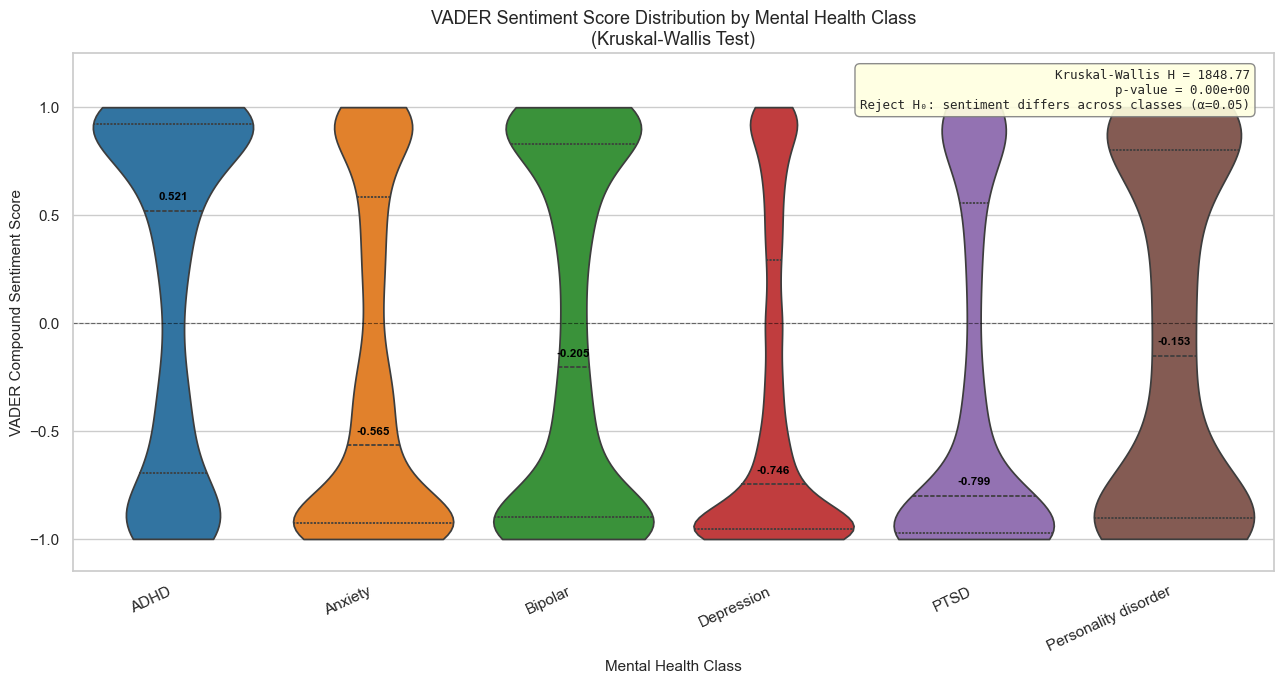

In [9]:
CLASS_ORDER = sorted(df_kw['label'].unique())
palette = sns.color_palette('tab10', len(CLASS_ORDER))

fig, ax = plt.subplots(figsize=(13, 7))

sns.violinplot(
    data=df_kw,
    x='label', y='Vader_variable',
    order=CLASS_ORDER,
    palette=palette,
    inner='quartile',
    cut=0,
    ax=ax
)

for i, cls in enumerate(CLASS_ORDER):
    med = df_kw[df_kw['label'] == cls]['Vader_variable'].median()
    ax.text(i, med + 0.04, f'{med:.3f}', ha='center', va='bottom',
            fontsize=8.5, fontweight='bold', color='black')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

conclusion = (
    f'Kruskal-Wallis H = {stat_kw:.2f}\n'
    f'p-value = {p_kw:.2e}\n'
    + ('Reject H₀: sentiment differs across classes (α=0.05)' if p_kw < 0.05
       else 'Fail to reject H₀ (α=0.05)')
)
ax.text(0.98, 0.97, conclusion,
        transform=ax.transAxes, va='top', ha='right',
        fontsize=9, family='monospace',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray', alpha=0.9))

ax.set_title('VADER Sentiment Score Distribution by Mental Health Class\n(Kruskal-Wallis Test)', fontsize=13)
ax.set_xlabel('Mental Health Class', fontsize=11)
ax.set_ylabel('VADER Compound Sentiment Score', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.set_ylim(-1.15, 1.25)
plt.tight_layout()
plt.show()

### Conclusion — Kruskal-Wallis Test

We reject H₀ (H = 1848.77, p ≈ 0). Sentiment scores differ systematically across at least one pair of mental health classes. The distributions are not all equal.

- Key finding: There is a clear and clinically meaningful gradient in median sentiment across classes:
  - ADHD (+0.521) — the only class with a positive median, consistent with energetic, hyperfocused, or celebratory posting behavior.
  - Bipolar (−0.205) — mildly negative median with a wide, bimodal violin shape, reflecting the intense emotional swings characteristic of these conditions.
  - Anxiety (−0.565), Depression (−0.746), and PTSD (−0.799) — the most negatively charged group, where the bulk of posts express distress, fear, or hopelessness.
- The violin plots reveal that this is not just about medians. ADHD has a single dominant positive peak. Depression and PTSD have heavy mass concentrated at very negative scores. Bipolar shows a near-hourglass shape. A single median does not adequately summarize this bimodal shape.
- Outliers: All classes contain posts scoring near ±1.0 (the VADER extremes), but the proportion of extreme-negative posts is far higher in Depression and PTSD.
- Feature correlation: Since "Vader_variable" separates classes so significantly (H = 1848.77), it is statistically validated as a high-value feature for multi-class classification. It is correlated with the label in a way that is both statistically and clinically interpretable.
- Implications: The bimodal nature of Bipolar distribution suggests this class will be hardest to classify correctly. The model will likely confuse it with both the ADHD and Depression/PTSD, which are positive-leaning and negative-leaning classes respectively. This further stresses the importance of techniques sensitive to distributional shape, such as gradient boosting or SVMs with RBF kernels, as these may outperform linear models. Class imbalance remains a key concern and should be addressed with stratified splits or weighted loss functions.